In [1]:
import torch
from torch import nn
from d2l import torch as d2l

# 1) Reset Gate:
#  Candidate를 만들 때 과거를 얼마나 참고할지 결정
#
# 2) Update Gate:
#  최종 State에서 과거 H와 Candidate를 어떤 비율로 섞을지 결정

In [2]:
# GRU Parameter Initialization

class GRUScratch(d2l.Module):
    
    num_inputs: int
    num_hiddens: int
    sigma: float
    
    def __init__(
        self,
        num_inputs: int,  # Input feature
        num_hiddens: int, # Hidden unit 수
        sigma: float = 1e-2,
    ) -> None:
        super().__init__()
        
        self.save_hyperparameters()
        
        def init_weight(
            *shape: int,
        ) -> nn.Parameter:
            return nn.Parameter(
                torch.randn(*shape) * sigma
            )
                
        def init_gate_parameters(
        ) -> tuple[
            nn.Parameter,
            nn.Parameter,
            nn.Parameter,
        ]: 

            # Input Weight     : [D, H]
            # Recurrent Weight : [H, H]
            # Bias             : [H]
            return (
                init_weight(
                    num_inputs,
                    num_hiddens,
                ),
                
                init_weight(
                    num_hiddens,
                    num_hiddens,
                ),
                
                nn.Parameter(
                    torch.zeros(num_hiddens)
                ),
            )
        
        # Update Gate:
        self.W_xz, self.W_hz, self.b_z = (
            init_gate_parameters()
        )
        
        # Reset Gate
        self.W_xr, self.W_hr, self.b_r = (
            init_gate_parameters()
        )
        
        # Candidate Hidden State
        self.W_xh, self.W_hh, self.b_h = (
            init_gate_parameters()
        )
        

In [3]:
# GRU Forward Computation

def gru_scratch_forward(
    self: GRUScratch,
    inputs: torch.Tensor,
    H: torch.Tensor | None = None,
) -> tuple[
    list[torch.Tensor],
    torch.Tensor,
]: 
    
    # Hidden State initialization
    if H is None:
        batch_size = inputs.shape[1]
        
        H = torch.zeros(
            (
                batch_size, 
                self.num_hiddens,
            ),
            device=inputs.device,
            dtype=inputs.dtype,
        )


    # 모든 time step의 Hidden State 저장
    outputs: list[torch.Tensor] = []
        
    # Inputs.shape: [T, B, D]
    for X in inputs:
    
        # X: [B, D]
        # H: [B, H]
        
        # Update Gate: [B, H]
        # 이전 Hidden State를 얼마나 유지할지 결정
        Z = torch.sigmoid(
            X @ self.W_xz
            + H @ self.W_hz
            + self.b_z
        )
        
        # Reset Gate: [B, H]:
        # Candidate를 만들 때 이전 Hidden State를 얼마나 참고할지 결정
        R = torch.sigmoid(
            X @ self.W_xr
            + H @ self.W_hr
            + self.b_r
        )
        
        # Candidate Hidden State: [B, H]
        # (R * H)로 이전 Hidden State를 조절한 뒤, 새로운 Hidden State 후보를 만듬
        H_tilde = torch.tanh(
            X @ self.W_xh
            + (R * H) @ self.W_hh
            + self.b_h
        )
        
        # Hidden State Update with Convex Combination
        H = (
            Z * H
            + (1 - Z) * H_tilde
        )
        
        # Hidden State 누적
        outputs.append(H)


    return outputs, H

setattr(
    GRUScratch,
    "forward",
    gru_scratch_forward,
)

In [ ]:
# GRU Shape and Parameter Check

batch_size = 2
num_steps = 3
num_inputs = 4
num_hiddens = 8

gru = GRUScratch(
    num_inputs=num_inputs,   # D
    num_hiddens=num_hiddens, # H
)

# [T, B, D] = [3, 2, 4]
inputs = torch.randn(
    num_steps,
    batch_size,
    num_inputs,
)

# [T, B, H] = [3, 2, 8]
outputs, final_H = gru(
    inputs
)

stacked_outputs = torch.stack(
    outputs,
    dim=0,
)

actual_num_parameters = sum(
    parameter.numel()
    for parameter in gru.parameters()
)

# 1. Update Gate: Z
# 2. Reset Gate: R
# 3. Candidate Hidden State: H_tilde
expected_num_parameters = 3 * (
    num_inputs * num_hiddens
    + num_hiddens * num_hiddens
    + num_hiddens
)

print(
    "Input shape:",
    tuple(inputs.shape),
)
print(
    "Output sequence:",
    tuple(stacked_outputs.shape),
)
print(
    "Final H:",
    tuple(final_H.shape),
)
print(
    "Parameter count:",
    actual_num_parameters,
)

Input shape: (3, 2, 4)
Output sequence: (3, 2, 8)
Final H: (2, 8)
Parameter count: 312


Vocabulary size: 28
Training device: cuda:0


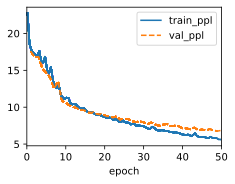

In [ ]:
# GRU Language Model Training

data = d2l.TimeMachine(
    batch_size=1024,
    num_steps=32,
)

# Character vocabulary size: V
vocab_size = len(
    data.vocab
)

gru = GRUScratch(
    num_inputs=vocab_size,
    num_hiddens=32,
)


# Data Flow:
#
# Token index                   : [B, T]
# Transpose & One-Hot sequence  : [T, B, V]
# GRU output                    : [T, B, H]
# Character logits              : [T, B, V]
model = d2l.RNNLMScratch(
    rnn=gru,
    vocab_size=vocab_size,
    lr=4,
)

trainer = d2l.Trainer(
    max_epochs=50,
    gradient_clip_val=1, # Gradient clipping: Exploding Gradient 방지
    num_gpus=1,
)

trainer.fit(
    model,
    data,
)

model_device = next(
    model.parameters()
).device

print(
    "Vocabulary size:",
    vocab_size,
)
print(
    "Training device:",
    model_device,
)